# Result- und Fehleranalyse der LLM-Labels

Dieses Notebook analysiert die Qualität der vom LLM vergebenen Labels (`task`, `sentiment`, `critical`):

- **a)** Übereinstimmung der beiden menschlichen Coder mit dem LLM (Prozent-Agreement & Cohen's Kappa)
- **b)** Übereinstimmung der Coder untereinander (Intercoder-Reliabilität)
- **c)** Metriken des LLM gegen den Goldstandard (Accuracy, F1 pro Klasse, Macro-/Weighted-F1) inkl. Fehleranalyse als Konfusionsmatrix-Heatmap (Outcome × Prediction)

**Datenbasis:**
- `chats_labeled_sample30_coder.csv` / `chats_labeled_sample30_coder2.csv`: 30er-Stichprobe, in der jeweils ein Coder die LLM-Labels überprüft hat. Spalten `task`, `sentiment`, `critical` = LLM; `task_coder`, `sentiment_coder`, `critical_coder` = Coder.
- Goldstandard (noch in Arbeit): CSV mit den konsentierten Labels pro Chat, siehe Abschnitt c).

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
)

DATA = Path("..") / "data"
PLOTS = Path("..") / "plots"

DIMENSIONS = ["task", "sentiment", "critical"]

# Feste Kategorienreihenfolge für Tabellen und Heatmaps
CATEGORIES = {
    "task": [
        "Informationssuche und Verständnis",
        "Lernen und Prüfungsvorbereitung",
        "Schreiben und Textarbeit",
        "Praktische Unterstützung und Strukturierung",
        "Technische und analytische Unterstützung",
    ],
    "sentiment": ["Freundlich", "Neutral", "Unfreundlich"],
    "critical": ["Ja", "Nein"],
}

pd.set_option("display.precision", 3)

In [3]:
CODER_FILES = {
    "Coder 1": DATA / "processed" / "control" / "chats_labeled_sample30_coder.csv",
    "Coder 2": DATA / "processed" / "control" / "chats_labeled_sample30_coder2.csv",
}

coder_data = {}
for name, path in CODER_FILES.items():
    if path.exists():
        df = pd.read_csv(path)
        coder_data[name] = df
        print(f"{name}: {len(df)} Chats geladen ({path})")
    else:
        print(f"{name}: Datei {path} noch nicht vorhanden – wird übersprungen.")

Coder 1: 32 Chats geladen (../data/processed/control/chats_labeled_sample30_coder.csv)
Coder 2: 32 Chats geladen (../data/processed/control/chats_labeled_sample30_coder2.csv)


## a) Übereinstimmung Coder ↔ LLM

Pro Coder und Label-Dimension: prozentuale Übereinstimmung und Cohen's Kappa (zufallskorrigiert). Als Faustregel nach Landis & Koch: κ > 0.60 = substanziell, κ > 0.80 = fast perfekt.

In [4]:
def agreement_stats(y1, y2):
    mask = y1.notna() & y2.notna()
    y1, y2 = y1[mask], y2[mask]
    return {
        "n": int(mask.sum()),
        "Agreement %": (y1 == y2).mean() * 100,
        "Cohen's Kappa": cohen_kappa_score(y1, y2),
    }


rows = []
for name, df in coder_data.items():
    for dim in DIMENSIONS:
        stats = agreement_stats(df[dim], df[f"{dim}_coder"])
        rows.append({"Vergleich": f"{name} vs. LLM", "Dimension": dim, **stats})

coder_llm_agreement = pd.DataFrame(rows)
coder_llm_agreement

,Vergleich,Dimension,n,Agreement %,Cohen's Kappa
0,Coder 1 vs. LLM,task,32,100.000,1.000
1,Coder 1 vs. LLM,sentiment,32,87.500,0.733
2,Coder 1 vs. LLM,critical,32,93.750,0.765
3,Coder 2 vs. LLM,task,32,100.000,1.000
4,Coder 2 vs. LLM,sentiment,32,84.375,0.677
5,Coder 2 vs. LLM,critical,32,93.750,0.765


### Abweichende Fälle Coder ↔ LLM

Welche Chats hat der jeweilige Coder anders gelabelt als das LLM?

In [5]:
for name, df in coder_data.items():
    for dim in DIMENSIONS:
        diff = df[df[dim] != df[f"{dim}_coder"]]
        if len(diff):
            print(f"\n{name} – {dim}: {len(diff)} Abweichung(en)")
            print(
                diff[["chat_id", dim, f"{dim}_coder"]]
                .rename(columns={dim: "LLM", f"{dim}_coder": "Coder"})
                .to_string(index=False)
            )


Coder 1 – sentiment: 4 Abweichung(en)
 chat_id          LLM   Coder
      36 Unfreundlich Neutral
      42 Unfreundlich Neutral
      45 Unfreundlich Neutral
      68 Unfreundlich Neutral

Coder 1 – critical: 2 Abweichung(en)
 chat_id  LLM Coder
      26 Nein    Ja
      95 Nein    Ja

Coder 2 – sentiment: 5 Abweichung(en)
 chat_id          LLM      Coder
      27      Neutral Freundlich
      36 Unfreundlich    Neutral
      42 Unfreundlich    Neutral
      68 Unfreundlich    Neutral
      80   Freundlich    Neutral

Coder 2 – critical: 2 Abweichung(en)
 chat_id  LLM Coder
      26 Nein    Ja
      95 Nein    Ja


## b) Übereinstimmung der Coder untereinander (Intercoder-Reliabilität)

Die Coder-Dateien werden über `chat_id` gemerged und die `*_coder`-Spalten verglichen.

In [6]:
if len(coder_data) == 2:
    c1, c2 = coder_data["Coder 1"], coder_data["Coder 2"]
    merged = c1.merge(c2, on="chat_id", suffixes=("_c1", "_c2"))
    print(f"Gemeinsame Chats: {len(merged)}")

    rows = []
    for dim in DIMENSIONS:
        stats = agreement_stats(merged[f"{dim}_coder_c1"], merged[f"{dim}_coder_c2"])
        rows.append({"Vergleich": "Coder 1 vs. Coder 2", "Dimension": dim, **stats})
    intercoder_agreement = pd.DataFrame(rows)
    display(intercoder_agreement)

    for dim in DIMENSIONS:
        diff = merged[merged[f"{dim}_coder_c1"] != merged[f"{dim}_coder_c2"]]
        if len(diff):
            print(f"\nAbweichungen {dim}: {len(diff)}")
            print(
                diff[["chat_id", f"{dim}_coder_c1", f"{dim}_coder_c2"]]
                .rename(columns={f"{dim}_coder_c1": "Coder 1", f"{dim}_coder_c2": "Coder 2"})
                .to_string(index=False)
            )
else:
    print("Intercoder-Vergleich noch nicht möglich – es liegt erst eine Coder-Datei vor.")

Gemeinsame Chats: 32


,Vergleich,Dimension,n,Agreement %,Cohen's Kappa
0,Coder 1 vs. Coder 2,task,32,100.000,1.000
1,Coder 1 vs. Coder 2,sentiment,32,90.625,0.765
2,Coder 1 vs. Coder 2,critical,32,100.000,1.000



Abweichungen sentiment: 3
 chat_id    Coder 1      Coder 2
      27    Neutral   Freundlich
      45    Neutral Unfreundlich
      80 Freundlich      Neutral


## c) LLM-Metriken gegen den Goldstandard

**Der Goldstandard existiert noch nicht.** Der Code ist bereits fertig ("trocken") geschrieben und läuft automatisch, sobald die Datei vorliegt.

Erwartetes Format von `GOLD_PATH` — eine CSV mit einer Zeile pro Chat und den konsentierten Labels in denselben Textkategorien wie die LLM-Labels:

| Spalte | Inhalt |
|---|---|
| `chat_id` | ID des Chats (zum Mergen mit den LLM-Labels) |
| `task_gold` | Goldstandard-Label Task |
| `sentiment_gold` | Goldstandard-Label Sentiment (`Freundlich`/`Neutral`/`Unfreundlich`) |
| `critical_gold` | Goldstandard-Label Critical (`Ja`/`Nein`) |

Die LLM-Prädiktionen (`task`, `sentiment`, `critical`) werden über `chat_id` aus der Stichproben-Datei dazugemergt.

In [7]:
GOLD_PATH = DATA / "processed" / "control" / "goldstandard_sample30.csv"  # Pfad ggf. anpassen

gold = None
if GOLD_PATH.exists():
    gold_labels = pd.read_csv(GOLD_PATH)
    # LLM-Labels aus der Stichprobe dazumergen (Coder-2-Datei enthält die LLM-Spalten)
    llm_labels = pd.read_csv(CODER_FILES["Coder 2"])[["chat_id"] + DIMENSIONS]
    gold = gold_labels.merge(llm_labels, on="chat_id", how="inner")
    print(f"Goldstandard: {len(gold_labels)} Chats, davon {len(gold)} mit LLM-Labels gematcht.")
else:
    print(f"Goldstandard-Datei {GOLD_PATH} existiert noch nicht – Abschnitt c) wird übersprungen.")

Goldstandard: 32 Chats, davon 32 mit LLM-Labels gematcht.


In [8]:
if gold is not None:
    rows = []
    for dim in DIMENSIONS:
        y_true = gold[f"{dim}_gold"]
        y_pred = gold[dim]
        rows.append({
            "Dimension": dim,
            "n": len(y_true),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Macro F1": f1_score(y_true, y_pred, average="macro"),
            "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
            "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        })
    llm_metrics = pd.DataFrame(rows)
    display(llm_metrics)

,Dimension,n,Accuracy,Macro F1,Weighted F1,Cohen's Kappa
0,task,32,1.000,1.000,1.000,1.000
1,sentiment,32,0.844,0.607,0.899,0.658
2,critical,32,0.938,0.881,0.932,0.765


### F1 pro Klasse

Precision, Recall und F1 je Kategorie (Klassen mit wenigen Gold-Fällen sind entsprechend unsicher — `support` beachten).

In [9]:
if gold is not None:
    for dim in DIMENSIONS:
        print(f"=== {dim} ===")
        print(classification_report(gold[f"{dim}_gold"], gold[dim], zero_division=0))

=== task ===
                                             precision    recall  f1-score   support

          Informationssuche und Verständnis       1.00      1.00      1.00        13
            Lernen und Prüfungsvorbereitung       1.00      1.00      1.00         4
Praktische Unterstützung und Strukturierung       1.00      1.00      1.00         2
                   Schreiben und Textarbeit       1.00      1.00      1.00         1
   Technische und analytische Unterstützung       1.00      1.00      1.00        12

                                   accuracy                           1.00        32
                                  macro avg       1.00      1.00      1.00        32
                               weighted avg       1.00      1.00      1.00        32

=== sentiment ===
              precision    recall  f1-score   support

  Freundlich       0.88      1.00      0.93         7
     Neutral       1.00      0.80      0.89        25
Unfreundlich       0.00      0.00     

### Fehleranalyse: Konfusionsmatrix-Heatmaps (Outcome × Prediction)

Zeilen = Goldstandard (Outcome), Spalten = LLM-Prädiktion. Die Diagonale sind korrekte Klassifikationen; alles abseits der Diagonale sind Fehler.

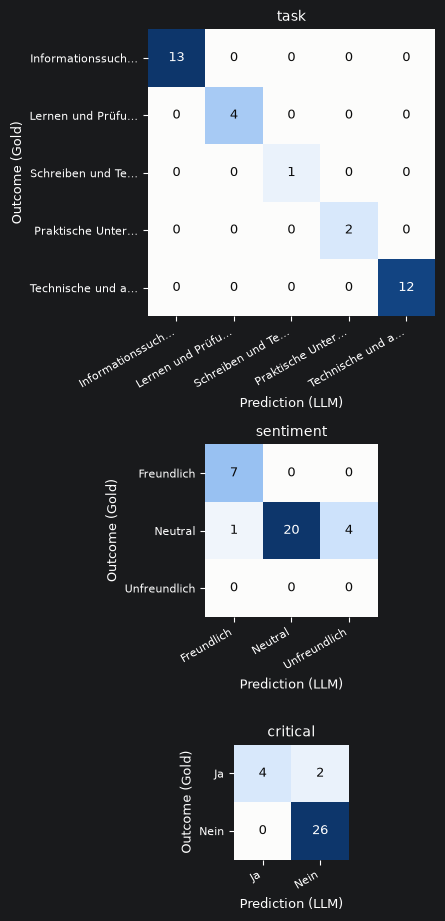

In [16]:
# Einfarbige sequenzielle Blau-Rampe (hell -> dunkel) für Häufigkeiten
BLUES = LinearSegmentedColormap.from_list(
    "seq_blue", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)


def plot_confusion(ax, y_true, y_pred, labels, title):
    labels = [l for l in labels if l in set(y_true) | set(y_pred)]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    ax.imshow(cm, cmap=BLUES, vmin=0, vmax=cm.max())
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    short = [l if len(l) <= 18 else l[:16] + "…" for l in labels]
    ax.set_xticklabels(short, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_xlabel("Prediction (LLM)", fontsize=9)
    ax.set_ylabel("Outcome (Gold)", fontsize=9)
    ax.set_title(title, fontsize=10)
    thresh = cm.max() / 2
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j, i, cm[i, j], ha="center", va="center", fontsize=9,
                color="white" if cm[i, j] > thresh else "#0b0b0b",
            )
    for spine in ax.spines.values():
        spine.set_visible(False)


if gold is not None:
    # Anzahl tatsächlich vorkommender Kategorien je Dimension -> Höhe der Teilplots
    used_labels = {
        dim: [
            l for l in CATEGORIES[dim]
            if l in set(gold[f"{dim}_gold"]) | set(gold[dim])
        ]
        for dim in DIMENSIONS
    }
    ratios = [len(used_labels[dim]) for dim in DIMENSIONS]

    # Konfusionsmatrizen untereinander (eine Spalte, eine Zeile pro Dimension)
    fig, axes = plt.subplots(
        len(DIMENSIONS), 1,
        figsize=(6, 3.2 * len(DIMENSIONS)),
        gridspec_kw={"height_ratios": ratios},
    )
    for ax, dim in zip(np.atleast_1d(axes), DIMENSIONS):
        plot_confusion(ax, gold[f"{dim}_gold"], gold[dim], CATEGORIES[dim], dim)
    #fig.suptitle("Konfusionsmatrizen: Goldstandard (Outcome) × LLM-Prädiktion", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(PLOTS / "20_llm_confusion_heatmaps.png", dpi=200, bbox_inches="tight")
    fig.savefig(PLOTS / "20_llm_confusion_heatmaps.pdf", dpi=200, bbox_inches="tight")

    plt.show()

### Falsch klassifizierte Chats im Detail

In [11]:
if gold is not None:
    for dim in DIMENSIONS:
        errors = gold[gold[f"{dim}_gold"] != gold[dim]]
        if len(errors):
            print(f"\n=== {dim}: {len(errors)} Fehler ===")
            print(
                errors[["chat_id", f"{dim}_gold", dim]]
                .rename(columns={f"{dim}_gold": "Gold", dim: "Prediction"})
                .to_string(index=False)
            )


=== sentiment: 5 Fehler ===
 chat_id    Gold   Prediction
      36 Neutral Unfreundlich
      42 Neutral Unfreundlich
      45 Neutral Unfreundlich
      68 Neutral Unfreundlich
      80 Neutral   Freundlich

=== critical: 2 Fehler ===
 chat_id Gold Prediction
      26   Ja       Nein
      95   Ja       Nein


## Zusammenfassung

Alle Agreement- und Metrik-Tabellen kompakt in einer Übersicht:

In [12]:
summary_parts = [coder_llm_agreement]
if len(coder_data) == 2:
    summary_parts.append(intercoder_agreement)
summary = pd.concat(summary_parts, ignore_index=True)
display(summary)
if gold is not None:
    display(llm_metrics)

,Vergleich,Dimension,n,Agreement %,Cohen's Kappa
0,Coder 1 vs. LLM,task,32,100.000,1.000
1,Coder 1 vs. LLM,sentiment,32,87.500,0.733
2,Coder 1 vs. LLM,critical,32,93.750,0.765
3,Coder 2 vs. LLM,task,32,100.000,1.000
4,Coder 2 vs. LLM,sentiment,32,84.375,0.677
5,Coder 2 vs. LLM,critical,32,93.750,0.765
6,Coder 1 vs. Coder 2,task,32,100.000,1.000
7,Coder 1 vs. Coder 2,sentiment,32,90.625,0.765
8,Coder 1 vs. Coder 2,critical,32,100.000,1.000


,Dimension,n,Accuracy,Macro F1,Weighted F1,Cohen's Kappa
0,task,32,1.000,1.000,1.000,1.000
1,sentiment,32,0.844,0.607,0.899,0.658
2,critical,32,0.938,0.881,0.932,0.765
